In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import numpy as np


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'CPU'
print(f"Running on: {device.upper()}")

Running on: CUDA


In [2]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_data = datasets.CIFAR10('./data', train=True,  download=True, transform=transform)
test_data = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data,  batch_size=64, shuffle=False)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print(f"Train samples : {len(train_data)}")
print(f"Test samples : {len(test_data)}")
print(f"Classes : {classes}")

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


Train samples : 50000
Test samples : 10000
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model  = CIFAR10_CNN().to(device)
print(model)


CIFAR10_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_fe

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / len(loader.dataset)
    return avg_loss, accuracy

In [8]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / len(loader.dataset)
    return avg_loss, accuracy

In [10]:
EPOCHS = 20

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss' : [], 'test_acc' : []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if epoch % 4 == 0:
      print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | Test Loss: {test_loss:.4f}  | Test Acc: {test_acc:.1f}%")

Epoch  4/20 | Train Loss: 0.2426 | Train Acc: 91.3% | Test Loss: 0.7732  | Test Acc: 79.6%
Epoch  8/20 | Train Loss: 0.2092 | Train Acc: 92.4% | Test Loss: 0.8866  | Test Acc: 79.4%
Epoch 12/20 | Train Loss: 0.1775 | Train Acc: 93.6% | Test Loss: 0.9498  | Test Acc: 78.6%
Epoch 16/20 | Train Loss: 0.1642 | Train Acc: 94.1% | Test Loss: 1.0218  | Test Acc: 79.1%
Epoch 20/20 | Train Loss: 0.1504 | Train Acc: 94.6% | Test Loss: 1.0092  | Test Acc: 79.7%


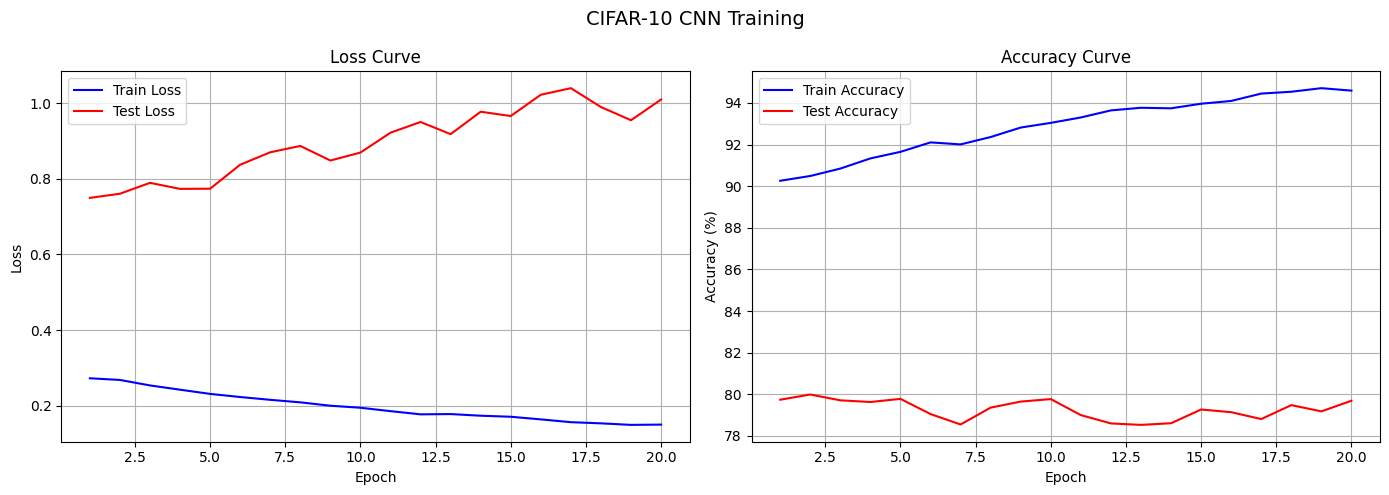

In [11]:
epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs, history['train_loss'], label='Train Loss', color='blue')
ax1.plot(epochs, history['test_loss'],  label='Test Loss',  color='red')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(epochs, history['train_acc'], label='Train Accuracy', color='blue')
ax2.plot(epochs, history['test_acc'],  label='Test Accuracy',  color='red')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('CIFAR-10 CNN Training', fontsize=14)
plt.tight_layout()
plt.show()